<a href="https://colab.research.google.com/github/devinaalifia0-alt/Visi-Komputer/blob/main/ekstraksi_bentuk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

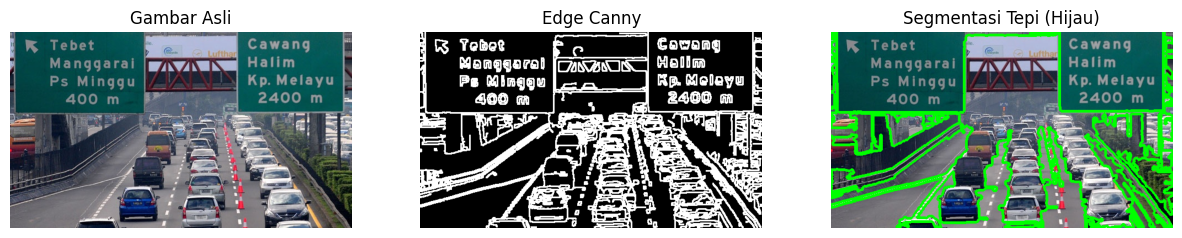

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD GAMBAR
# =========================
img = cv2.imread('159840_620.jpg')

if img is None:
    raise Exception("❌ Gambar tidak ditemukan!")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
output = img_rgb.copy()

# =========================
# PREPROCESSING
# =========================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Edge detection
edges = cv2.Canny(blur, 50, 150)

# Perjelas edge
kernel = np.ones((3,3), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)

# =========================
# CONTOUR
# =========================
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# =========================
# GAMBAR GARIS HIJAU
# =========================
for c in contours:
    area = cv2.contourArea(c)

    if area < 1500:
        continue

    # warna hijau
    cv2.drawContours(output, [c], -1, (0,255,0), 3)

# =========================
# VISUALISASI (3 OUTPUT)
# =========================
plt.figure(figsize=(15,5))

# 1. Gambar asli
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis('off')

# 2. Edge Canny
plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Canny")
plt.axis('off')

# 3. Contour hijau
plt.subplot(1,3,3)
plt.imshow(output)
plt.title("Segmentasi Tepi (Hijau)")
plt.axis('off')

plt.show()